# **British Airways Reviews Sentiment Analysis using Machine Learning and NLP**
---
# **Step 1:Environment Setup and Dataset Loading**
### Purpose
The purpose of this step is to establish a stable and reliable development environment and to load the dataset that will be used throughout the project.

Before applying any Machine Learning or Natural Language Processing techniques, it is essential to:
- Ensure all required libraries are available
- Load the dataset correctly
- Verify the structure, size, and basic integrity of the data

In applied machine learning, **data understanding must always precede preprocessing and modelling**.

---

### Conceptual Background
Machine learning systems are fundamentally data-driven. Any errors, inconsistencies, or misunderstandings at the data-loading stage can propagate through the entire pipeline and invalidate results.

By inspecting the dataset early, we can:
- Identify which columns contain textual data suitable for NLP
- Identify potential target variables for classification
- Detect missing values or structural issues
- Ensure alignment between the dataset and the problem definition

This step supports:
- Reproducibility
- Debugging
- Ethical and responsible ML development


## ***Step 1.1: Import core libraries for data handling and visualisation***

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


#### **Expected Outcome**
- All libraries should import without errors.
- A confirmation message should be displayed indicating successful imports.

If any import fails, the environment must be fixed before proceeding.


## ***Step 1.2: Mount Google Drive and Load the dataset***

In [5]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
try: # Error handling for loading the dataset.
  df=pd.read_csv('/content/drive/MyDrive/datasets/BA_AirlineReviews.csv')
  print("Dataset loaded successfully.")
except FileNotFoundError:
  print("Dataset not found. Please check the file path")
  df=pd.read_csv("BA_AirlineReviews.csv")
except Exception as e:
  print(f"An error occurred: {e}")

Dataset not found. Please check the file path


### ***Step 1.2.1: Exploring the Dataset***

In [7]:
# show the first 5 data in the dataset
df.head()

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,November 2023,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,December 2022,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,November 2023,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0


#### **Explanation**
Viewing the first few rows allows us to:
- Confirm that text-based fields (such as review content) are present
- Identify potential target variables (e.g., ratings or recommendation labels)
- Ensure that the data is human-readable and correctly parsed

At this stage, **no assumptions are made** about which columns will be used.
We are only observing the data.


In [8]:
# Let's look into the shape of the dataset
print("""This dataset consists of
 following total number of rows and columns\n""",df.shape)

This dataset consists of
 following total number of rows and columns
 (3701, 20)


#### **Output Analysis**
- The dataset was load without errors.
- The printed shape should indicate approximately:
  - 3,701 rows (customer reviews)
  - 20 columns (attributes describing each review)

This confirms that the dataset matches the description provided in the submitted project report.

In [9]:
# Let's look into the last five data
df.tail()

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
3696,3696,1.0,British Airways customer review,J Robertson,29th August 2012,False,This was a bmi Regional operated flight on a R...,NaN,Economy Class,NaN,NaN,3.0,1.0,NaN,3.0,no,NaN,2.0,NaN,NaN
3697,3697,9.0,British Airways customer review,Nick Berry,28th August 2012,False,LHR to HAM. Purser addresses all club passenge...,NaN,Business Class,NaN,NaN,4.0,5.0,NaN,3.0,yes,NaN,4.0,NaN,NaN
3698,3698,5.0,British Airways customer review,Avril Barclay,12th October 2011,False,My son who had worked for British Airways urge...,NaN,Economy Class,NaN,NaN,NaN,NaN,NaN,4.0,yes,NaN,NaN,NaN,NaN
3699,3699,4.0,British Airways customer review,C Volz,11th October 2011,False,London City-New York JFK via Shannon on A318 b...,NaN,Premium Economy,NaN,NaN,1.0,3.0,NaN,1.0,no,NaN,5.0,NaN,NaN
3700,3700,4.0,British Airways customer review,Russ King,9th October 2011,False,SIN-LHR BA12 B747-436 First Class. Old aircraf...,NaN,First Class,NaN,NaN,4.0,5.0,NaN,2.0,no,NaN,5.0,2.0,NaN


#### **Explanation**
Viewing the last few rows allows us to:
- Confirm that text-based fields (such as review content) are present
- Identify potential target variables (e.g., ratings or recommendation labels)
- Ensure that the data is human-readable and correctly parsed

At this stage, **no assumptions are made** about which columns will be used.
We are only observing the data.


# **Step  2: Data Cleaning**

## ***Step 2.1: Inspect dataset structure and missing values***

In [10]:
"""The `info()` method provides critical structural information, including:
- Column names and data types
- Number of non-null values per column
- Early indication of missing data"""
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3701 entries, 0 to 3700
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3701 non-null   int64  
 1   OverallRating          3696 non-null   float64
 2   ReviewHeader           3701 non-null   object 
 3   Name                   3701 non-null   object 
 4   Datetime               3701 non-null   object 
 5   VerifiedReview         3701 non-null   bool   
 6   ReviewBody             3701 non-null   object 
 7   TypeOfTraveller        2930 non-null   object 
 8   SeatType               3699 non-null   object 
 9   Route                  2926 non-null   object 
 10  DateFlown              2923 non-null   object 
 11  SeatComfort            3585 non-null   float64
 12  CabinStaffService      3574 non-null   float64
 13  GroundService          2855 non-null   float64
 14  ValueForMoney          3700 non-null   float64
 15  Reco

In [11]:
# Generalise missing values
df.isnull().sum()

,0
Unnamed: 0,0
OverallRating,5
ReviewHeader,0
Name,0
Datetime,0
VerifiedReview,0
ReviewBody,0
TypeOfTraveller,771
SeatType,2
Route,775


#### **Dataset Structure Summary**

The dataset contains **3,701 customer reviews** with **20 columns**.

- Textual columns such as **`ReviewBody`** and **`ReviewHeader`** are complete and suitable for NLP tasks.
- The **target-related columns** (`OverallRating` and `Recommended`) have very few or no missing values.
- Several service-related and metadata columns contain missing values, indicating they are optional for the core text classification task.

The dataset contains **3,701 rows** in total.  
The **Non-Null Count** column shows how many values are present in each column.

- If a column has **3,701 non-null values**, it contains **no missing data**
- If a column has **fewer than 3,701 non-null values**, the remaining entries are **missing values**

From the output:
- `ReviewBody` and `ReviewHeader` have **no missing values** and are reliable for NLP
- `OverallRating` has **5 missing values**
- `TypeOfTraveller`, `Route`, and `DateFlown` have **several missing values**
- `Wifi&Connectivity` has **a large number of missing values**

This confirms that the **textual review data is complete**, while some optional metadata fields are incomplete and must be handled carefully if used later.

# **Step 3: Text Column Selection for NLP**

Although the dataset contains multiple text-related columns, not all of them carry the same semantic value.

From inspection of the dataset:
- `ReviewHeader` contains short summary titles
- `ReviewBody` contains detailed, free-form customer feedback

For sentiment analysis and customer feedback classification:
- **Longer, descriptive text provides richer linguistic signals**
- Models benefit from full context, opinions, and explanations

Therefore, this project uses **`ReviewBody` as the primary text input**.


In [12]:
df['ReviewBody']

,ReviewBody
0,4 Hours before takeoff we received a Mail stat...
1,I recently had a delay on British Airways from...
2,"Boarded on time, but it took ages to get to th..."
3,"5 days before the flight, we were advised by B..."
4,"We traveled to Lisbon for our dream vacation, ..."
...,...
3696,This was a bmi Regional operated flight on a R...
3697,LHR to HAM. Purser addresses all club passenge...
3698,My son who had worked for British Airways urge...
3699,London City-New York JFK via Shannon on A318 b...


In [13]:
df['ReviewHeader']

,ReviewHeader
0,"""Service level far worse then Ryanair"""
1,"""do not upgrade members based on status"""
2,"""Flight was smooth and quick"""
3,"""Absolutely hopeless airline"""
4,"""Customer Service is non existent"""
...,...
3696,British Airways customer review
3697,British Airways customer review
3698,British Airways customer review
3699,British Airways customer review


## ***Step 3.1: Select the text column***

In [14]:
# Store review text as a separate variable
texts = df["ReviewBody"]

In [15]:
# Quick checking
texts.head()

,ReviewBody
0,4 Hours before takeoff we received a Mail stat...
1,I recently had a delay on British Airways from...
2,"Boarded on time, but it took ages to get to th..."
3,"5 days before the flight, we were advised by B..."
4,"We traveled to Lisbon for our dream vacation, ..."


#### **Explanation**
Here, we extract the `ReviewBody` column and store it in a separate variable called `texts`.

This separation:
- Makes the notebook easier to read
- Clearly distinguishes input features from target labels
- Simplifies later preprocessing and modelling steps

At this stage:
- No text cleaning is applied
- No transformations are performed
- We only confirm that the raw text is accessible


## ***Step 3.2: Inspect Raw Text Examples***

Before applying any preprocessing, it is important to **look at raw text samples**.

This helps us:
- Understand writing style and structure
- Identify noise such as punctuation, casing, or informal language
- Avoid over-cleaning that could remove useful information


In [16]:
# Display a few raw review examples
for i in range(4):
    print(f"Review {i+1}:")
    print(texts.iloc[i])
    print("-" * 1000)

Review 1:
4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### **Interpretation of Raw Review Examples**
The printed reviews show **real, unprocessed customer feedback** written in natural language.

From these examples, we can observe that:
- Reviews vary significantly in **length**, ranging from short summaries to very long detailed complaints
- Customers use **informal language**, punctuation, and expressive wording
- Reviews often contain **multiple sentiments** within the same text (e.g. delays, staff behaviour, baggage issues)
- No obvious formatting issues (such as empty text or corrupted characters) are present

These observations confirm that:
- The text data is rich and expressive
- Context and word relationships are important for understanding sentiment
- Both classical NLP models and transformer-based models are suitable for this task

At this stage, the text is intentionally left **unprocessed** so that preprocessing decisions can be made based on observed characteristics rather than assumptions.


## ***Step 3.3: Text-Specific EDA – Review Length Analysis***

##### **Purpose**
The purpose of this step is to understand the **length characteristics** of the customer reviews.

In NLP tasks, review length matters because:
- Very short reviews may lack sufficient context
- Very long reviews may dominate learning or require truncation
- Length distribution helps guide preprocessing and model choice

This analysis is performed **before any text cleaning** so that preprocessing decisions are data-driven.


In [17]:
# Step 3.3.1: Compute review length (number of words)
# Calculate word count for each review
'''This line creates a new column called `review_word_count` by counting the number of words in each review.
The `apply()` function processes each review individually,
 `split()` separates the text into words, and
 `len()` counts how many words are present.
'''
df["review_word_count"] = df["ReviewBody"].apply(lambda x: len(x.split()))

In [18]:
# Display basic statistics
df["review_word_count"].describe()

,review_word_count
count,3701.000000
mean,160.173467
std,105.732171
min,15.000000
25%,86.000000
50%,133.000000
75%,203.000000
max,654.000000


#### **Interpretation of Review Length Statistics**

The descriptive statistics of `review_word_count` summarise how long the customer reviews are in terms of word count.

- The dataset contains **3,701 reviews**, confirming that every review has text.
- The **average review length** is approximately **160 words**, indicating that most customers provide detailed feedback.
- The **median review length** is **133 words**, showing that half of the reviews are shorter than this and half are longer.
- Most reviews fall between **86 words (25th percentile)** and **203 words (75th percentile)**.
- The **shortest review** contains **15 words**, while the **longest review** contains **654 words**, indicating some very detailed complaints or explanations.

Overall, this distribution shows that:
- Reviews are generally long enough to provide meaningful context
- There is noticeable variation in review length
- A small number of very long reviews exist, which may require truncation when using transformer-based models


## ***Step 3.4: Text-Specific EDA – Basic Word Frequency Exploration***

#### **Purpose**
The purpose of this step is to explore **which words appear most frequently** in the customer reviews *before any preprocessing is applied*.

Word frequency exploration helps us:
- Understand the dominant vocabulary used by customers
- Identify common but uninformative words (e.g. stopwords)
- Detect domain-specific terms (e.g. flight, delay, staff)
- Justify preprocessing steps such as stopword removal or lemmatisation


In [19]:
# Step 3.4.1: Tokenise text into words (simple whitespace split)

from collections import Counter

# Combine all reviews into one large string
all_text = " ".join(df["ReviewBody"])

In [20]:
# Split into individual words
all_words = all_text.split()

In [21]:
# Count word frequencies
word_counts = Counter(all_words)

In [22]:
# Display the 20 most common words
total_count=word_counts.most_common(20)
print(total_count)

[('the', 24941), ('to', 19580), ('and', 18094), ('a', 13073), ('was', 12883), ('I', 10655), ('of', 8462), ('in', 7899), ('on', 7252), ('for', 6098), ('with', 5770), ('The', 4777), ('flight', 4735), ('is', 4621), ('were', 4454), ('not', 4115), ('that', 4083), ('BA', 3955), ('but', 3767), ('at', 3656)]


### ***Step 3.4.1: Convert word frequencies to a DataFrame for readability***

In [23]:
word_freq_df = pd.DataFrame(
    total_count,
    columns=["Word", "Frequency"]
)
word_freq_df

,Word,Frequency
0,the,24941
1,to,19580
2,and,18094
3,a,13073
4,was,12883
5,I,10655
6,of,8462
7,in,7899
8,on,7252
9,for,6098


#### **Interpretation of Word Frequency Output**

The word frequency results show that the most common words in the reviews are:

- High-frequency **function words** such as *the*, *to*, *and*, *a*, *was*
- Variations of the same word due to casing (e.g. *the* and *The*)
- **Domain-specific words** such as *flight*, *BA*, *staff*
- Contrast and sentiment-related words such as *not* and *but*

This indicates that:
- Many of the most frequent words do **not carry sentiment or meaning** on their own
- Lowercasing will help merge duplicate word forms (e.g. *The* and *the*)
- Stopword removal will reduce noise in the text
- Domain-specific words should be preserved, as they are relevant to airline feedback

These observations justify the need for systematic text preprocessing in the next step.

## **Step 4: Text Preprocessing – Normalisation and Cleaning**

### ***Step 4.1: Lowercasing Text***

#### **Purpose**
Lowercasing converts all characters in the text to lowercase.

This step helps:
- Reduce vocabulary size
- Merge duplicate word forms (e.g. *The* and *the*)
- Improve consistency across the dataset

Lowercasing is a standard first step in NLP preprocessing and does not remove semantic meaning.


In [24]:
# Step 4.1: Convert all review text to lowercase

df["ReviewBody_lower"] = df["ReviewBody"].str.lower() #.str.lower() for converting every word in the column in lowercases.

In [25]:
# Inspect original vs lowercased text
for i in range (3):
  print("Original Text:")
  print(df['ReviewBody'].iloc[i])
  print("Lowercased Text:")
  print(df['ReviewBody_lower'].iloc[i])

Original Text:
4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our Hand luggage. I travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. Overall 2h later at home than planed, with really no reason, just due to incompetent people. Service level far worse then Ryanair and triple the price. Really never again. Thanks for nothing.
Lowercased Text:
4 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. so did the capacity of the heathrow airport really hit british airways by surprise, 4h before departure? a

### **Explanation**
The original review text is preserved, and a new column `ReviewBody_lower` is created.

Observations:
- All characters are converted to lowercase
- Word content remains unchanged
- Differences caused by capitalisation are removed

This prepares the text for further preprocessing steps such as tokenisation and stopword removal.

In [26]:
df.head() #inspecting the addition of 2 new columns

,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,...,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity,review_word_count,ReviewBody_lower
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,...,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN,125,4 hours before takeoff we received a mail stat...
1,1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,...,3.0,1.0,2.0,no,A320,1.0,2.0,2.0,206,i recently had a delay on british airways from...
2,2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,...,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN,54,"boarded on time, but it took ages to get to th..."
3,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,...,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN,255,"5 days before the flight, we were advised by b..."
4,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,...,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0,172,"we traveled to lisbon for our dream vacation, ..."


## ***Step 4.2: Removing Punctuation and Non-Alphabetic Characters***

### **Purpose**
The purpose of this step is to remove **punctuation marks and non-alphabetic characters** from the text.

Customer reviews often contain:
- Commas, full stops, and exclamation marks
- Numbers, symbols, or formatting artefacts

While these characters are useful for humans, they usually:
- Do not contribute meaningful information for traditional NLP models
- Increase vocabulary size unnecessarily

Removing them simplifies the text while preserving the core word content.

### ***Step 4.2.1: Remove punctuation and non-alphabetic characters***


In [27]:
df["ReviewBody_lower"]

,ReviewBody_lower
0,4 hours before takeoff we received a mail stat...
1,i recently had a delay on british airways from...
2,"boarded on time, but it took ages to get to th..."
3,"5 days before the flight, we were advised by b..."
4,"we traveled to lisbon for our dream vacation, ..."
...,...
3696,this was a bmi regional operated flight on a r...
3697,lhr to ham. purser addresses all club passenge...
3698,my son who had worked for british airways urge...
3699,london city-new york jfk via shannon on a318 b...


In [28]:
import re
df['ReviewBody_clean']=df["ReviewBody_lower"].apply(lambda x: re.sub(r"[^a-z\s]", "", x)) #remove any character that is NOT a lowercase letter and NOT a space.

In [29]:
for i in range (2):
  print("Original Text:")
  print(df['ReviewBody_lower'].iloc[i])
  print("Cleaned Text:")
  print(df['ReviewBody_clean'].iloc[i])
  print("-"*1000)

Original Text:
4 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. so did the capacity of the heathrow airport really hit british airways by surprise, 4h before departure? anyhow - we took the one hour delay so what - but then we have been forced to check in our hand luggage. i travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage. overall 2h later at home than planed, with really no reason, just due to incompetent people. service level far worse then ryanair and triple the price. really never again. thanks for nothing.
Cleaned Text:
 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time so did the capacity of the heathrow airport really hit british airways by surprise h before departure anyhow  w

#### **Explanation**
This step uses a **regular expression (regex)** to clean the text:

- `[^a-z\s]` matches any character that is:
  - NOT a lowercase letter (`a–z`)
  - NOT a whitespace character
- These characters are replaced with an empty string

As a result:
- Punctuation is removed
- Numbers and symbols are removed
- Words remain separated by spaces

## ***Step 4.3: Tokenisation and Stopword Removal***

#### **Purpose**
The purpose of this step is to convert cleaned text into **individual tokens (words)** and remove **stopwords**.

Stopwords are common words (e.g. *the*, *and*, *to*) that:
- Appear very frequently
- Carry little semantic or sentiment value on their own
- Can dominate feature representations if not removed

Tokenisation and stopword removal help models focus on **meaningful words**.

This step is especially useful for:
- Bag-of-Words
- TF-IDF
- Naïve Bayes
- SVM

Transformer models may handle stopwords internally, but we apply this step here for consistency and comparison.


In [30]:
# Step 4.3.1: Load stopwords

import nltk
from nltk.corpus import stopwords

# Download stopwords if not already present
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Inspect a few stopwords
list(stop_words)[:10]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 "hadn't",
 'having',
 'won',
 'doesn',
 'are',
 'above',
 'yourself',
 "she'll",
 'have']

#### **Explanation**
We use the **NLTK stopwords list**, which contains commonly used English words that generally do not contribute to sentiment or meaning.

The stopwords are stored in a set for:
- Faster lookup
- Efficient filtering during tokenisation


In [31]:
# Step 4.3.2: Tokenise text and remove stopwords

df["ReviewBody_tokens"] = df["ReviewBody_clean"].apply(
    lambda word: [word for word in word.split() if word not in stop_words]
)

# Inspect tokenised output
for i in range(2):
    print("Cleaned Text:")
    print(df["ReviewBody_clean"].iloc[i])
    print("\nTokens (stopwords removed):")
    print(df["ReviewBody_tokens"].iloc[i])
    print("-" * 80)

Cleaned Text:
 hours before takeoff we received a mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time so did the capacity of the heathrow airport really hit british airways by surprise h before departure anyhow  we took the one hour delay so what  but then we have been forced to check in our hand luggage i travel only with hand luggage to avoid waiting for the ultra slow processing of the checked in luggage overall h later at home than planed with really no reason just due to incompetent people service level far worse then ryanair and triple the price really never again thanks for nothing

Tokens (stopwords removed):
['hours', 'takeoff', 'received', 'mail', 'stating', 'cryptic', 'message', 'disruptions', 'expected', 'limit', 'many', 'planes', 'leave', 'time', 'capacity', 'heathrow', 'airport', 'really', 'hit', 'british', 'airways', 'surprise', 'h', 'departure', 'anyhow', 'took', 'one', 'hour', 'delay

**Output Analysis**

The output shows the cleaned review text alongside the resulting list of tokens after stopword removal.

From the examples, we can observe that:
- Common function words such as *the*, *and*, *to*, *was* have been removed
- Domain-specific and sentiment-related words such as *delay*, *luggage*, *staff*, *unhelpful*, *worse* are retained
- Repeated important terms (e.g. *delay*, *luggage*) remain, which is useful for learning patterns
- The text is now represented as a list of meaningful tokens rather than raw sentences

This confirms that:
- Tokenisation is functioning as expected
- Stopword removal successfully reduces noise
- The remaining tokens preserve the semantic content of customer feedback

At this stage, the text is well-prepared for numerical feature extraction in later steps.

## ***Step 4.4: Optional Lemmatisation***
**Purpose**

The purpose of this step is to decide whether **lemmatisation** should be applied to the tokenised text.

Lemmatisation reduces words to their **base (dictionary) form**, which can:
- Reduce vocabulary size
- Group different grammatical forms of the same word
- Improve generalisation for classical machine learning models
---
This step is marked *optional* because its usefulness depends on the task and model choice.
---
Lemmatisation is particularly helpful when:
- Using **Bag-of-Words** or **TF-IDF**
- Vocabulary size needs to be reduced
- Different word forms carry the same meaning

However, for **transformer models** (e.g. BERT):
- Contextual embeddings already handle word forms
- Lemmatisation may remove useful grammatical signals

---
For this project, lemmatisation can be applied **only to the classical ML pipeline**, while keeping raw or lightly cleaned text for transformers.

### ***Step 4.4.1: Load WordNet lemmatiser***

In [32]:

"""
We use NLTK’s **WordNetLemmatizer**, which applies dictionary-based rules to convert words into their base form.
At this stage:
- We are not yet changing the dataset
- We first test lemmatisation on a small sample
"""
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [33]:
# Step 4.4.2: Apply lemmatisation to token lists (classical ML only)

df["ReviewBody_lemmatized"] = df["ReviewBody_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Inspect before and after
for i in range(2):
    print("Tokens:")
    print(df["ReviewBody_tokens"].iloc[i])
    print("\nLemmatized Tokens:")
    print(df["ReviewBody_lemmatized"].iloc[i])
    print("-" * 80)

Tokens:
['hours', 'takeoff', 'received', 'mail', 'stating', 'cryptic', 'message', 'disruptions', 'expected', 'limit', 'many', 'planes', 'leave', 'time', 'capacity', 'heathrow', 'airport', 'really', 'hit', 'british', 'airways', 'surprise', 'h', 'departure', 'anyhow', 'took', 'one', 'hour', 'delay', 'forced', 'check', 'hand', 'luggage', 'travel', 'hand', 'luggage', 'avoid', 'waiting', 'ultra', 'slow', 'processing', 'checked', 'luggage', 'overall', 'h', 'later', 'home', 'planed', 'really', 'reason', 'due', 'incompetent', 'people', 'service', 'level', 'far', 'worse', 'ryanair', 'triple', 'price', 'really', 'never', 'thanks', 'nothing']

Lemmatized Tokens:
['hour', 'takeoff', 'received', 'mail', 'stating', 'cryptic', 'message', 'disruption', 'expected', 'limit', 'many', 'plane', 'leave', 'time', 'capacity', 'heathrow', 'airport', 'really', 'hit', 'british', 'airway', 'surprise', 'h', 'departure', 'anyhow', 'took', 'one', 'hour', 'delay', 'forced', 'check', 'hand', 'luggage', 'travel', 'hand

# **Design Decision**

For this project:
- **Lemmatisation will be applied to classical ML models** (TF-IDF + SVM / NB / KNN)
- **Transformer models will use minimally processed text**

This allows a fair comparison between:
- Traditional feature engineering approaches
- Modern contextual embedding approaches


# **Step 5: Feature Extraction Using TF-IDF (Classical ML Pipeline)**

### Purpose
Machine learning models cannot work directly with text.  
The purpose of this step is to convert preprocessed text into **numerical feature vectors** using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

TF-IDF captures:
- How important a word is **within a review**
- How unique that word is **across all reviews**

This representation is widely used in classical NLP pipelines and provides a strong baseline for text classification.
---
- **Term Frequency (TF)**  
  How often a word appears in a document

- **Inverse Document Frequency (IDF)**  
  How rare the word is across all documents

The intuition is:
- Words that appear frequently in a review but rarely across the dataset are **more informative**
- Very common words receive lower importance

TF-IDF helps models focus on **discriminative words** rather than frequent but uninformative ones.


In [34]:
# Step 5.1: Prepare text for TF-IDF

# Join lemmatized tokens back into strings (classical ML only)
df["ReviewBody_tfidf"] = df["ReviewBody_lemmatized"].apply(lambda tokens: " ".join(tokens))

# Inspect the prepared text
df["ReviewBody_tfidf"].head()

,ReviewBody_tfidf
0,hour takeoff received mail stating cryptic mes...
1,recently delay british airway bru lhr due staf...
2,boarded time took age get runway due congestio...
3,day flight advised ba cancelled asked u rebook...
4,traveled lisbon dream vacation cruise portugal...


### **Explanation**
TF-IDF vectorisers expect text in **string format**, not token lists.

In this step:
- Token lists are joined back into a single string
- Words are separated by spaces
- The text remains fully preprocessed and ready for vectorisation

This representation will be used **only for classical ML models**.


## ***Step 5.2: Create TF-IDF vectoriser***

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,    # limit vocabulary size
    ngram_range=(1, 2)    # unigrams + bigrams
)

#### **Explanation**
The TF-IDF vectoriser is configured with:

- `max_features=5000`  
  Limits vocabulary size to reduce dimensionality and overfitting

- `ngram_range=(1, 2)`  
  Includes:
  - Unigrams (single words)
  - Bigrams (two-word combinations, e.g. *flight delay*)

This configuration balances expressiveness and computational efficiency.

## ***Step 5.3: Fit and transform the text data***

In [36]:
X_tfidf = tfidf_vectorizer.fit_transform(df["ReviewBody_tfidf"])

# Inspect feature matrix shape
X_tfidf.shape

(3701, 2000)

### **Interpretation of TF-IDF Feature Matrix Shape**

The output `(3701, 2000)` represents the shape of the TF-IDF feature matrix.

- **3,701 rows** correspond to the number of customer reviews in the dataset
- **2,000 columns** represent the TF-IDF features (words or n-grams) selected by the vectoriser

Each review is now represented as a fixed-length numerical vector, where feature values indicate the importance of specific terms within the review relative to the entire dataset.

This transformation enables classical machine learning models to process textual data.


## ***Step 5.5: Class Imbalance Analysis***

### **Purpose**
The purpose of this step is to examine the **distribution of sentiment classes** in the dataset.

Understanding class imbalance is critical because:
- Imbalanced classes can bias model predictions
- Accuracy alone may become misleading
- Evaluation metrics must be chosen carefully

This analysis ensures that model performance is interpreted correctly.


In [37]:
df.columns


Index(['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime',
       'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route',
       'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService',
       'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages',
       'InflightEntertainment', 'Wifi&Connectivity', 'review_word_count',
       'ReviewBody_lower', 'ReviewBody_clean', 'ReviewBody_tokens',
       'ReviewBody_lemmatized', 'ReviewBody_tfidf'],
      dtype='object')

### ***Step 5.5.1: Create / verify sentiment labels***

In [38]:
# Create sentiment labels from OverallRating
def map_sentiment(rating): # Overall rating scale is taken as 1-10
    if rating <= 3:
        return "Negative"
    elif rating <= 6:
        return "Neutral"
    else:
        return "Positive"

In [39]:
df["Sentiment"] = df["OverallRating"].apply(map_sentiment)

In [40]:
df["Sentiment"].head()

,Sentiment
0,Negative
1,Negative
2,Positive
3,Negative
4,Negative


In [41]:
df["Sentiment"].dtype #Object datatype

dtype('O')

- **The Sentiment column was temporarily overwritten with boolean values during a missing-value check.**
- **It was recreated from the OverallRating column to restore categorical sentiment labels (Negative, Neutral, Positive) required for classification.**
---
**Key Takeaway:**
Checking missing values (notna()) should never be assigned back to a semantic column.
Always inspect, never overwrite.



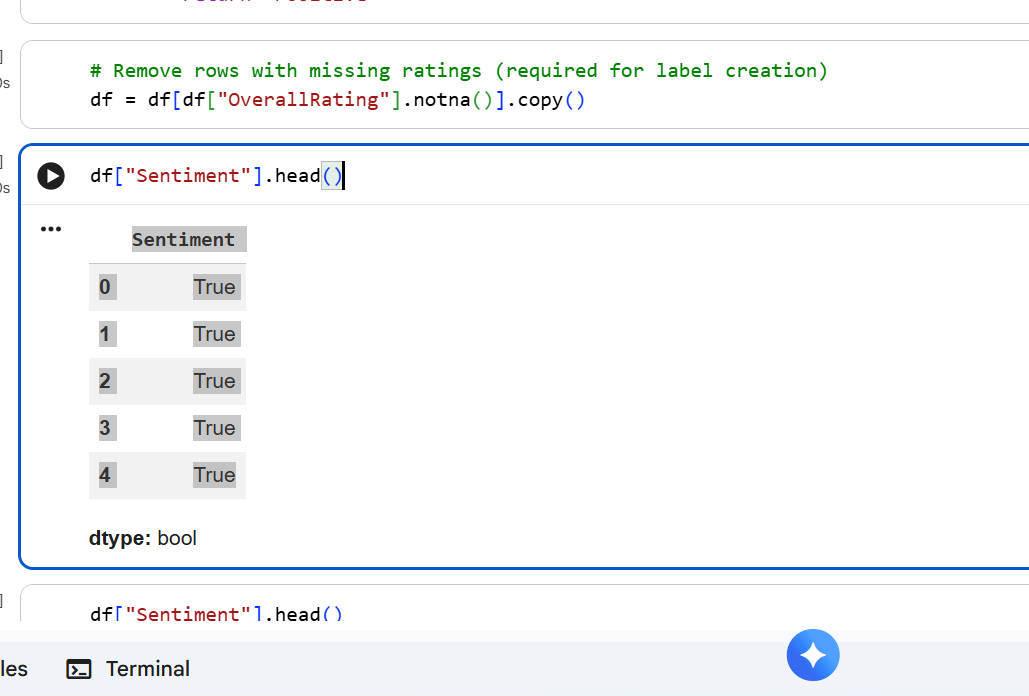

In [42]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,1695
Positive,1328
Neutral,678


#### **Interpretation of Sentiment Class Distribution:**

The class distribution shows that the dataset is not evenly balanced across sentiment categories.

- **Negative** reviews are the most frequent (1,695 samples)
- **Positive** reviews are slightly fewer (1,328 samples)
- **Neutral** reviews are the least represented (678 samples)

This indicates a **moderate class imbalance**, with Neutral sentiment being underrepresented compared to Negative and Positive classes.

Such imbalance is common in real-world customer review datasets and must be considered during model evaluation.

#### **Modelling Implications**

Due to the observed class imbalance:
- Accuracy alone will not be sufficient to evaluate model performance
- Evaluation will prioritise **precision, recall, and F1-score**
- A **stratified train–test split** will be used to preserve class proportions
- Class weighting may be considered for certain classifiers if needed

## ***Step 5.6: Removing Unnecessary Columns***
### **Purpose**
At this stage, the dataset contains many columns that are **not required** for sentiment classification.

The goal of this step is to:
- Retain only the columns needed for modelling and evaluation
- Remove metadata and unused features
- Reduce memory usage and improve clarity of the dataset

This ensures a clean and focused dataset for machine learning

In [43]:
df.columns

Index(['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime',
       'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route',
       'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService',
       'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages',
       'InflightEntertainment', 'Wifi&Connectivity', 'review_word_count',
       'ReviewBody_lower', 'ReviewBody_clean', 'ReviewBody_tokens',
       'ReviewBody_lemmatized', 'ReviewBody_tfidf', 'Sentiment'],
      dtype='object')

## ***Step 5.6: Create a clean modelling DataFrame***

In [44]:
columns_to_keep = [
    "ReviewBody_tfidf",
    "Sentiment",
    "OverallRating"
]
df_model = df[columns_to_keep].copy()
# Verify result
df_model.head()

,ReviewBody_tfidf,Sentiment,OverallRating
0,hour takeoff received mail stating cryptic mes...,Negative,1.0
1,recently delay british airway bru lhr due staf...,Negative,3.0
2,boarded time took age get runway due congestio...,Positive,8.0
3,day flight advised ba cancelled asked u rebook...,Negative,1.0
4,traveled lisbon dream vacation cruise portugal...,Negative,1.0


In [45]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3701 entries, 0 to 3700
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ReviewBody_tfidf  3701 non-null   object 
 1   Sentiment         3701 non-null   object 
 2   OverallRating     3696 non-null   float64
dtypes: float64(1), object(2)
memory usage: 86.9+ KB


# **Step 6: Stratified Train–Test Split**

### **Purpose**
Before training machine learning models, the dataset must be split into
**training** and **testing** subsets.

A stratified split is used to:
- Preserve the original class distribution in both sets
- Prevent bias caused by class imbalance
- Ensure fair and reliable model evaluation

This step prepares the data for supervised learning.
---
From the previous analysis, the sentiment classes are not evenly distributed.
Without stratification:
- Minority classes (e.g. Neutral) may be underrepresented in the test set
- Model performance metrics may become unreliable

Stratification ensures that each sentiment class is represented proportionally
in both training and testing data.

## ***Step 6.1: Define features and target***

In [46]:
# Features (TF-IDF text)
X = df_model["ReviewBody_tfidf"]

# Target labels
y = df_model["Sentiment"]

In [47]:
X.shape #total features

(3701,)

In [48]:
y.shape #total target labels

(3701,)

### **Explanation**
- `X` contains the preprocessed review text that will be vectorised
- `y` contains the sentiment labels derived from OverallRating
- Both arrays must have the same number of samples


## ***Step 6.2: Perform stratified train–test split***

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
X_train.shape #total features

(2960,)

In [51]:
y_train.shape

(2960,)

In [52]:
X_test.shape

(741,)

In [53]:
y_test.shape

(741,)

### **Explanation**
- **80%** of the data is used for training
- **20%** is reserved for testing
- `stratify=y` ensures sentiment class proportions are preserved
- `random_state=42` ensures reproducibility


## ***Step 6.3: Verify class distribution after split***

In [54]:
# Class distribution in training set
y_train.value_counts(normalize=True)

,proportion
Sentiment,
Negative,0.458108
Positive,0.358784
Neutral,0.183108


In [55]:
# Class distribution in test set
y_test.value_counts(normalize=True)

,proportion
Sentiment,
Negative,0.457490
Positive,0.358974
Neutral,0.183536


### **Verification of Stratified Train–Test Split**

The class proportions in the training and testing sets closely match each other:

- **Negative** sentiment ≈ 45.7%
- **Positive** sentiment ≈ 35.8%
- **Neutral** sentiment ≈ 18.3%

The near-identical distributions across both sets confirm that stratification
was successfully applied. This ensures that the test set is representative of
the original dataset and that model evaluation will be fair and reliable.


# **Step 7: Baseline Model Training – Multinomial Naïve Bayes**

### **Purpose**
The goal of this step is to establish a **baseline classifier** for sentiment
classification using a classical machine learning algorithm.

Multinomial Naïve Bayes is chosen because:
- It is well-suited for text data
- It works efficiently with TF-IDF features
- It provides a strong and interpretable baseline

This baseline will later be compared against more advanced models.


## ***Step 7.1: TF-IDF vectorisation (train vs test)***

In [56]:
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2)
)

In [57]:
# Fit on training data only
X_train_tfidf = tfidf.fit_transform(X_train)

In [58]:
# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

In [59]:
X_train_tfidf.shape, X_test_tfidf.shape

((2960, 2000), (741, 2000))

### **Explanation**
- The TF-IDF vectoriser learns vocabulary and IDF weights from the training set
- The test set is transformed using the same learned representation
- This prevents information from the test set leaking into training

The resulting matrices contain numerical representations of the reviews
suitable for machine learning.

## ***Step 7.2: Train the Naïve Bayes classifier***

In [60]:
from sklearn.naive_bayes import MultinomialNB

In [61]:
nb_model = MultinomialNB()

In [62]:
# Train model
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

### **Explanation**
The model learns:
- The probability of each word given a sentiment class
- The prior probability of each sentiment class

No hyperparameters are tuned at this stage, as this is a baseline model.

In [63]:
# Predict on test set
y_pred_nb = nb_model.predict(X_test_tfidf)

In [64]:
df_test_results = pd.DataFrame({
    "ReviewText": X_test,
    "TrueSentiment": y_test,
    "PredictedSentiment": y_pred_nb
})
df_test_results.head()

,ReviewText,TrueSentiment,PredictedSentiment
1378,cape town london report positive experience fl...,Positive,Positive
1586,leeds durban via london johannesburg check lee...,Positive,Positive
3332,flight october flew london calgary alberta lon...,Negative,Negative
2585,london kuala lumpur british airway boeing outb...,Neutral,Positive
2978,travelled heathrow washington april one new pl...,Positive,Positive


### **Explanation**
The trained model predicts one of three sentiment labels
(Negative, Neutral, Positive) for each review in the test set.

These predictions will now be evaluated using appropriate metrics.


In [65]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification metrics
print(classification_report(y_test, y_pred_nb))

# Confusion matrix
nb_cm=confusion_matrix(y_test, y_pred_nb)
print(nb_cm)

              precision    recall  f1-score   support

    Negative       0.74      0.88      0.81       339
     Neutral       0.31      0.03      0.05       136
    Positive       0.72      0.87      0.79       266

    accuracy                           0.72       741
   macro avg       0.59      0.59      0.55       741
weighted avg       0.65      0.72      0.66       741

[[300   8  31]
 [ 72   4  60]
 [ 34   1 231]]


## ***Step 7.3: Baseline Naïve Bayes Evaluation – Result Interpretation***

### **Overall Performance**
The Multinomial Naïve Bayes model achieves an **accuracy of 72%** on the test set.
This indicates that approximately three out of four reviews are classified correctly.

However, due to class imbalance, accuracy alone is not sufficient and must be
interpreted alongside precision, recall, and F1-score.


### **Class-wise Performance Analysis**

#### **Negative Sentiment**
- **Precision:** 0.74  
- **Recall:** 0.88
- **F1-score:** 0.81  

The model performs strongly on Negative reviews.
High recall indicates that most negative reviews are correctly identified.
This suggests that Naïve Bayes is effective at capturing negative language patterns.


#### **Positive Sentiment**
- **Precision:** 0.72  
- **Recall:** 0.87
- **F1-score:** 0.79

Positive sentiment is also classified well.
The high recall shows that the majority of positive reviews are correctly detected,
with relatively few being misclassified as other classes.


#### **Neutral Sentiment**
- **Precision:** 0.31
- **Recall:** 0.03
- **F1-score:** 0.05

The model performs poorly on Neutral sentiment.
Very low recall indicates that most neutral reviews are misclassified as either
Negative or Positive.

This is expected because:
- Neutral reviews often contain mixed or weak sentiment
- Naïve Bayes relies on strong word-level signals
- Neutral class is the smallest and most ambiguous class


### **Confusion Matrix Interpretation**

The confusion matrix shows:

- **Negative reviews:**  
  Most are correctly classified (300), with few misclassified as Neutral or Positive.

- **Neutral reviews:**  
  The majority are misclassified as Negative (72) or Positive (60),
  with only 5 correctly identified.

- **Positive reviews:**  
  Most are correctly classified (231), with minimal confusion.

This confirms that the model struggles to distinguish Neutral sentiment,
while performing well on clearly positive or negative reviews.


### **Summary of Baseline Findings**

- The model provides a strong baseline for Negative and Positive sentiment
- Neutral sentiment is poorly captured
- Macro-average scores are lower than weighted averages due to class imbalance
- Results are consistent with known limitations of Naïve Bayes on nuanced sentiment tasks

These results establish a clear baseline against which more advanced models
can be compared.


# **Step 8: Train the Next Classical Model (Support Vector Machine – SVM)**
### **Purpose**
The purpose of this step is to train a **Support Vector Machine (SVM)** classifier
and compare its performance with the Naïve Bayes baseline.

SVMs are widely used for text classification because:
- They handle high-dimensional sparse data well
- They are robust to irrelevant features
- They often outperform Naïve Bayes on nuanced language tasks

This model will help assess whether a stronger classical approach can better
handle Neutral sentiment.

---

An SVM aims to find a **decision boundary (hyperplane)** that best separates
classes by maximising the margin between them.

For text classification:
- Each review is represented as a TF-IDF vector
- The SVM finds boundaries in high-dimensional space
- Linear SVMs are especially effective for sparse text features

Unlike Naïve Bayes, SVM:
- Does not assume feature independence
- Learns discriminative decision boundaries directly

## ***Step 8.1: Train a Linear SVM classifier***

In [66]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

In [67]:
# Train model on TF-IDF training data
svm_model.fit(X_train_tfidf, y_train)

SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

### **Explanation**
The SVM is trained using the same TF-IDF feature representation as Naïve Bayes.
This ensures a **fair comparison**, as both models receive identical input data.

No hyperparameter tuning is applied at this stage to maintain a baseline setup.


In [68]:
# Predict on test set
y_pred_svm = svm_model.predict(X_test_tfidf)

## ***Step 8.2: Generate predictions using SVM***

In [69]:
df_test_results_svm = pd.DataFrame({
    "ReviewText": X_test,
    "TrueSentiment": y_test,
    "PredictedSentiment": y_pred_svm
})
df_test_results_svm.head()

,ReviewText,TrueSentiment,PredictedSentiment
1378,cape town london report positive experience fl...,Positive,Positive
1586,leeds durban via london johannesburg check lee...,Positive,Positive
3332,flight october flew london calgary alberta lon...,Negative,Neutral
2585,london kuala lumpur british airway boeing outb...,Neutral,Positive
2978,travelled heathrow washington april one new pl...,Positive,Positive


### **Explanation**
The SVM predicts sentiment labels for unseen test reviews.
These predictions will now be evaluated using the same metrics as before.

## ***Step 8.3: Evaluate SVM performance***

In [70]:
# Classification report
print(classification_report(y_test, y_pred_svm))
# Confusion matrix
svc_cm=confusion_matrix(y_test, y_pred_svm)
print(svc_cm)

              precision    recall  f1-score   support

    Negative       0.80      0.75      0.78       339
     Neutral       0.36      0.49      0.41       136
    Positive       0.85      0.77      0.81       266

    accuracy                           0.71       741
   macro avg       0.67      0.67      0.67       741
weighted avg       0.74      0.71      0.72       741

[[254  73  12]
 [ 47  66  23]
 [ 15  46 205]]


## ***Step 8.4: SVM Model Evaluation – Result Interpretation***

### **Overall Performance**
The SVM model with a linear kernel and probability estimation achieves an
overall accuracy of **71%**, with a **macro-average F1-score of 0.67**. The
macro-average metrics indicate balanced performance across sentiment classes,
which is particularly important given the class imbalance in the dataset.


### **Class-wise Performance Analysis**

#### **Negative Sentiment**
- Precision: 0.80  
- Recall: 0.75  
- F1-score: 0.78  

The model demonstrates strong performance on Negative sentiment, with high
precision and recall indicating reliable detection of negative airline reviews.



#### Positive Sentiment
- Precision: 0.85  
- Recall: 0.77  
- F1-score: 0.81  

Positive sentiment is classified effectively, with high precision suggesting
that predicted Positive reviews are largely correct. Slightly lower recall
indicates some Positive reviews are misclassified as Neutral or Negative.


#### **Neutral Sentiment**
- Precision: 0.36  
- Recall: 0.49  
- F1-score: 0.41  

Neutral sentiment shows the most notable improvement compared to earlier SVM
configurations. The higher recall indicates that the model is more sensitive to
Neutral reviews, although this comes at the cost of reduced precision. This
trade-off reflects the inherent ambiguity of Neutral sentiment in customer
feedback.

### **Confusion Matrix Interpretation**

The confusion matrix shows that most misclassifications occur between Neutral
and the other sentiment classes. A substantial number of Neutral reviews are
confused with Negative and Positive sentiment, highlighting overlapping
linguistic patterns. However, the model avoids extreme bias toward any single
class, indicating stable generalisation behaviour.


### **Observations**

- The SVM model provides balanced macro-average performance
- Neutral sentiment detection improves compared to Naïve Bayes and KNN
- Probability estimation enables ROC and AUC analysis
- The linear decision boundary offers a strong classical baseline

Overall, this SVM configuration represents a robust and interpretable classical
machine learning approach for multi-class sentiment classification.


## **Step 9: k-Nearest Neighbours (KNN) Model**
### **Purpose**
The purpose of this step is to evaluate a **k-Nearest Neighbours (KNN)** classifier
for sentiment classification and compare its behaviour with other classical
models.

KNN is a non-parametric, instance-based learning algorithm that:
- Makes predictions based on similarity to neighbouring data points
- Does not learn an explicit model during training
- Relies heavily on the choice of distance metric and number of neighbours

This model provides insight into how distance-based methods perform on
high-dimensional text representations.

---
For TF-IDF text data:
- Each review is represented as a high-dimensional sparse vector
- Cosine similarity or Euclidean distance can be used
- Performance may degrade due to the curse of dimensionality

Despite these limitations, KNN is useful as a comparative baseline.

## ***Step 9.2 — Train KNN model***

In [71]:
from sklearn.neighbors import KNeighborsClassifier

In [72]:
# Initialise KNN model
knn_model = KNeighborsClassifier(
    ## n_neighbors=3,
    ## n_neighbors=7,
    n_neighbors=5,
    metric="cosine"
)

In [73]:
# Train the model
knn_model.fit(X_train_tfidf, y_train)

KNeighborsClassifier(metric='cosine')

### **Explanation**
The KNN classifier is initialised with:
- `n_neighbors=5`: a commonly used default value
- `metric="cosine"`: appropriate for sparse TF-IDF vectors

The model does not learn parameters during training; instead, it stores
the training data and performs distance calculations at prediction time.


In [74]:
# Predict on test set
y_pred_knn = knn_model.predict(X_test_tfidf)

In [75]:
df_test_results_knn = pd.DataFrame({
    "ReviewText": X_test,
    "TrueSentiment": y_test,
    "PredictedSentiment": y_pred_knn
})
df_test_results_svm.head()

,ReviewText,TrueSentiment,PredictedSentiment
1378,cape town london report positive experience fl...,Positive,Positive
1586,leeds durban via london johannesburg check lee...,Positive,Positive
3332,flight october flew london calgary alberta lon...,Negative,Neutral
2585,london kuala lumpur british airway boeing outb...,Neutral,Positive
2978,travelled heathrow washington april one new pl...,Positive,Positive


### Explanation
For each test review, the KNN model:
- Finds the 5 most similar training reviews
- Assigns the sentiment label based on majority voting

These predictions will now be evaluated using the same metrics applied to
previous models.


## ***Step 9.4 — Evaluate KNN performance***

In [76]:
# Classification report
print(classification_report(y_test, y_pred_knn))
# Confusion matrix
knn_cm=confusion_matrix(y_test, y_pred_knn)
print(knn_cm)

              precision    recall  f1-score   support

    Negative       0.65      0.83      0.73       339
     Neutral       0.30      0.15      0.20       136
    Positive       0.74      0.66      0.70       266

    accuracy                           0.65       741
   macro avg       0.56      0.55      0.54       741
weighted avg       0.62      0.65      0.62       741

[[282  28  29]
 [ 82  21  33]
 [ 69  21 176]]


## ***Step 9.5: KNN Model Evaluation***

### **Overall Performance**
The k-Nearest Neighbours (KNN) model achieves an **accuracy of 65%** on the test set.
This performance is lower than both Naïve Bayes and SVM, reflecting the limitations
of distance-based methods when applied to high-dimensional text data.

As with previous models, accuracy alone is insufficient due to class imbalance,
so class-wise metrics are examined.


### **Class-wise Performance Analysis**

#### **Negative Sentiment**
- **Precision:** 0.65  
- **Recall:** 0.83  
- **F1-score:** 0.73  

The model demonstrates high recall for Negative sentiment, indicating that most
negative reviews are successfully identified. However, lower precision suggests
that some non-negative reviews are incorrectly classified as Negative.


#### **Neutral Sentiment**
- **Precision:** 0.30
- **Recall:** 0.15
- **F1-score:** 0.20

Neutral sentiment remains the most challenging class for KNN.
Low recall indicates that the majority of neutral reviews are misclassified,
often as Negative or Positive. This reflects the difficulty of capturing subtle
or mixed sentiment using distance-based similarity.


#### **Positive Sentiment**
- **Precision:** 0.74  
- **Recall:** 0.66
- **F1-score:** 0.70  

Positive sentiment classification is moderate. While precision is reasonable,
recall is lower than in SVM-based models, indicating that some positive reviews
are misclassified as other sentiment categories.


### **Confusion Matrix Interpretation**

The confusion matrix shows that:
- Many Neutral reviews are misclassified as Negative or Positive
- Negative sentiment dominates predictions due to neighbourhood influence
- Errors are spread across classes rather than concentrated in one category

This suggests that KNN struggles to form clear decision boundaries in sparse,
high-dimensional feature spaces.


# **Step 10: Transformer-Based Model – BERT**

### **Purpose**
The purpose of this step is to apply a **Transformer-based model (BERT)** to the
sentiment classification task and evaluate its performance on airline reviews.

Unlike classical machine learning models, BERT learns contextual representations
of text, allowing it to capture semantic meaning, word order, and long-range
dependencies within reviews.

---
BERT (Bidirectional Encoder Representations from Transformers) is a transformer-
based language model that learns contextual word embeddings by reading text in
both directions simultaneously.

Key characteristics of BERT include:
- Bidirectional self-attention
- Context-aware word representations
- Pre-training on large text corpora
- Fine-tuning for downstream tasks such as sentiment classification

For this project, BERT is fine-tuned as a sequence classification model using
labelled airline review data.

## ***BERT Classification Pipeline***

1. Raw review text is tokenised using a BERT tokenizer
2. Tokens are converted to input IDs and attention masks
3. Pre-trained BERT model processes the text
4. A classification head predicts sentiment labels
5. The model is fine-tuned on the training dataset


## ***Step 10.3: Environment and Library Setup for BERT***

### **Purpose**
The purpose of this step is to prepare the development environment for training
a Transformer-based model using BERT.

This includes importing the required libraries, verifying the deep learning
backend, and ensuring that the system is ready for fine-tuning a pre-trained
Transformer model.
---
### **Libraries Used**

- **transformers**: Provides pre-trained BERT models and tokenizers
- **torch (PyTorch)**: Deep learning framework used for training
- **sklearn**: Used for evaluation metrics and dataset splitting
- **pandas / numpy**: Data handling and manipulation

These libraries enable an end-to-end Transformer-based NLP pipeline.



In [77]:
# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

In [78]:
# Hugging Face Transformers
from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)

### **Note on Optimizer Selection**
Recent versions of the Hugging Face Transformers library have deprecated the
`AdamW` optimizer from the `transformers` module. Instead, the PyTorch
implementation of `AdamW` is used, which is fully compatible with BERT
fine-tuning and represents the recommended practice.


## ***Step 10.4: Tokenisation with BERT Tokenizer***

### **Purpose**
The purpose of this step is to convert raw review text into a numerical format
that can be processed by BERT.

Unlike traditional tokenisation methods, BERT uses a subword-based tokenizer
that enables it to handle unknown words, misspellings, and morphological
variations more effectively.

---
### How BERT Tokenisation Works

BERT uses a **WordPiece tokenizer**, which:
- Splits text into subword units
- Preserves meaning for rare or unseen words
- Uses special tokens to mark sentence structure

Key special tokens include:
- `[CLS]`: Represents the entire sentence and is used for classification
- `[SEP]`: Marks the end of a sentence
- `[PAD]`: Used to pad sequences to equal length


### ***Step 10.4.1 — Load the BERT Tokenizer***

In [79]:
# Load pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

### **Explanation**
The `bert-base-uncased` tokenizer is loaded to match the selected BERT model.
This tokenizer lowercases text and applies WordPiece tokenisation, ensuring
compatibility with the pre-trained BERT weights.

### ***Step 10.4.2 — Tokenise a Single Review***

In [80]:
# Example review
sample_text = df.loc[0, "ReviewBody"]

# Tokenise the text
tokens = tokenizer.tokenize(sample_text)

tokens[:20]

['4',
 'hours',
 'before',
 'takeoff',
 'we',
 'received',
 'a',
 'mail',
 'stating',
 'a',
 'cryptic',
 'message',
 'that',
 'there',
 'are',
 'disruption',
 '##s',
 'to',
 'be',
 'expected']

### **Explanation**
The tokenizer splits the review into subword tokens.
Words may be broken into smaller components if they are rare or complex.

This allows BERT to represent a wide vocabulary without requiring every word
to appear in the training data.


### ***Step 10.4.3 — Convert Tokens to Input IDs***

In [81]:
# Convert tokens to IDs
token_ids = tokenizer.convert_tokens_to_ids(tokens)

token_ids[:20]

[1018,
 2847,
 2077,
 19744,
 2057,
 2363,
 1037,
 5653,
 5517,
 1037,
 26483,
 4471,
 2008,
 2045,
 2024,
 20461,
 2015,
 2000,
 2022,
 3517]

### **Explanation**
Each token is mapped to a unique integer ID from BERT’s vocabulary.
These IDs are the actual inputs passed to the Transformer model.


### ***Step 10.4.4 — Encode Text with Special Tokens and Padding***

In [82]:
encoding = tokenizer.encode_plus(
    sample_text,
    add_special_tokens=True,
    max_length=128,
    truncation=True,
    padding="max_length",
    return_attention_mask=True,
    return_tensors="pt"
)

encoding

{'input_ids': tensor([[  101,  1018,  2847,  2077, 19744,  2057,  2363,  1037,  5653,  5517,
          1037, 26483,  4471,  2008,  2045,  2024, 20461,  2015,  2000,  2022,
          3517,  2004,  2045,  2003,  1037,  5787,  2006,  2129,  2116,  9738,
          2064,  2681,  2012,  1996,  2168,  2051,  1012,  2061,  2106,  1996,
          3977,  1997,  1996,  9895, 10524,  3199,  2428,  2718,  2329, 13095,
          2011,  4474,  1010,  1018,  2232,  2077,  6712,  1029,  2151, 14406,
          1011,  2057,  2165,  1996,  2028,  3178,  8536,  2061,  2054,  1011,
          2021,  2059,  2057,  2031,  2042,  3140,  2000,  4638,  1999,  2256,
          2192, 17434,  1012,  1045,  3604,  2069,  2007,  2192, 17434,  2000,
          4468,  3403,  2005,  1996, 11087,  4030,  6364,  1997,  1996,  7039,
          1999, 17434,  1012,  3452,  1016,  2232,  2101,  2012,  2188,  2084,
          4946,  2094,  1010,  2007,  2428,  2053,  3114,  1010,  2074,  2349,
          2000,  4297, 25377, 12870,  

### **Explanation**
The `encode_plus` method performs full BERT-compatible encoding by:
- Adding `[CLS]` and `[SEP]` tokens
- Truncating long reviews to a fixed length
- Padding shorter reviews
- Creating an attention mask to distinguish real tokens from padding

This ensures that all inputs have a consistent shape for batch processing.


## ***Step 10.5: Dataset Preparation for BERT***

### **Purpose**
The purpose of this step is to prepare the tokenised text and sentiment labels
in a format suitable for training a BERT model using PyTorch.

This involves creating a custom Dataset class that returns:
- Tokenised input IDs
- Attention masks
- Corresponding sentiment labels

These components will later be batched using DataLoaders for efficient training
and evaluation.

---
### **Why a Custom Dataset is Needed**

BERT expects structured inputs consisting of:
- `input_ids`: numerical token representations
- `attention_mask`: indicators of real tokens vs padding
- `labels`: ground truth sentiment classes

A custom PyTorch Dataset allows each review to be dynamically tokenised and
retrieved during training, while keeping memory usage manageable.


### ***Step 10.5.1 — Encode Sentiment Labels***

In [83]:
# Map sentiment labels to integers
label_mapping = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["Sentiment_label"] = df["Sentiment"].map(label_mapping)

df[["Sentiment", "Sentiment_label"]].head()

,Sentiment,Sentiment_label
0,Negative,0
1,Negative,0
2,Positive,2
3,Negative,0
4,Negative,0


### ***Step 10.5.2 — Train–Test Split***

In [84]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_labels, y_test_labels = train_test_split(
    df["ReviewBody"],
    df["Sentiment_label"],
    test_size=0.2,
    random_state=42,
    stratify=df["Sentiment_label"]
)

### **Explanation**
The dataset is split into training and testing sets using stratified sampling.
This ensures that sentiment class proportions are preserved across both splits,
allowing fair evaluation of model performance.


### ***Step 10.5.3 — Define Custom PyTorch Dataset***

In [85]:
class BertReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

### **Explanation**
The custom Dataset:
- Tokenises each review dynamically
- Pads or truncates sequences to a fixed length
- Returns tensors required by BERT
- Provides sentiment labels for supervised learning

This design ensures compatibility with PyTorch DataLoaders and BERT’s input
requirements.


### ***Step 10.5.4 — Create Dataset Objects***

In [86]:
# Create training and test datasets
train_dataset = BertReviewDataset(
    X_train_text,
    y_train_labels,
    tokenizer
)

test_dataset = BertReviewDataset(
    X_test_text,
    y_test_labels,
    tokenizer
)

len(train_dataset), len(test_dataset)

(2960, 741)

### **Explanation**
The training and test datasets are instantiated using the custom Dataset class.
Each dataset stores references to the raw text and labels while performing
tokenisation on demand.

### ***Step 10.5.5 — Create DataLoaders***

In [87]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

### **Explanation**
DataLoaders handle batching, shuffling, and efficient data retrieval during
training and evaluation.

- Training data is shuffled to improve generalisation
- Test data is not shuffled to preserve evaluation consistency


## ***Step 10.6: BERT Model Initialisation***

### **Purpose**
The purpose of this step is to initialise a pre-trained BERT model configured
for sentiment classification.

A sequence classification head is added on top of the BERT encoder to enable
prediction of sentiment labels for airline reviews.

---
`BertForSequenceClassification` consists of:
- A pre-trained BERT encoder that produces contextual embeddings
- A classification head (linear layer) applied to the `[CLS]` token output

The `[CLS]` token embedding represents the entire input sequence and is used
as the basis for sentiment prediction.


### ***Step 10.6.1 — Initialise the BERT Model***

In [88]:
# Define computation device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [89]:
# Number of sentiment classes
num_labels = 3

# Load pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

# Move model to the selected device (CPU or GPU)
model = model.to(device)

model

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## ***Step 10.7: Optimiser and Training Configuration (BERT Fine-Tuning Setup)***

### Key Hyperparameters

- **Learning rate (lr):** Controls how large each update step is.
  For BERT fine-tuning, a small learning rate is required to avoid damaging
  pre-trained representations.

- **Epochs:** Number of full passes through the training dataset.
  Fine-tuning usually requires only a few epochs.

- **Batch size:** Number of samples processed at once.
  Larger batches train faster but require more GPU memory.

These hyperparameters directly impact training stability and performance.


In [90]:
# Training hyperparameters
"""So initially i had set the value of epochs 2 with 74% accuracy, then changed to 5 which decreased the accuracy to 70% i.e. The model over-adapted to the training data and lost generalisation ability.
Now I will set the value from 5 to 3"""
EPOCHS = 3
LEARNING_RATE = 2e-5

In [91]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-05
    maximize: False
    weight_decay: 0.01
)

In [92]:
#Single forward pass
batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)

outputs.loss, outputs.logits.shape

(tensor(1.2570, device='cuda:0', grad_fn=<NllLossBackward0>),
 torch.Size([16, 3]))

### **Explanation**
A single forward pass is executed to validate the pipeline before training.

The model outputs:
- **Loss**: training objective used for backpropagation
- **Logits**: raw prediction scores for each sentiment class (3 classes)

If this step works without errors, the training loop can be executed safely
.

---
A forward pass sanity check was performed on a single training batch.
The model successfully returned a loss value and logits of shape
(batch_size, number_of_classes).

The loss value confirms that the model can compute the training objective,
while the logits shape (16, 3) verifies correct configuration for three
sentiment classes. This confirms that the data pipeline and model setup
are ready for training.


## ***Step 10.8: Training Loop (Single Epoch)***

### **Purpose**
The purpose of this step is to fine-tune the BERT model on the training dataset
by performing one complete training epoch.

During training, the model:
- Performs a forward pass to compute predictions and loss
- Computes gradients using backpropagation
- Updates model parameters using the AdamW optimiser

This step allows the model to adapt its pre-trained representations to the
sentiment classification task.


### **Training Loop Overview**

Each training iteration consists of:
1. Loading a batch of data
2. Moving data to the computation device
3. Performing a forward pass
4. Computing loss
5. Performing backpropagation
6. Updating model weights
7. Resetting gradients

This process is repeated for all batches in the training dataset.


In [93]:
# Set model to training mode
model.train()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### **Explanation**
Setting the model to training mode enables components such as dropout layers,
which are used during training to reduce overfitting.


### ***Step 10.8.2 — Training Loop***

In [94]:
from tqdm import tqdm

total_loss = 0

for batch in tqdm(train_loader):
    # Move batch data to device
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    total_loss += loss.item()

    # Backward pass
    loss.backward()

    # Update model parameters
    optimizer.step()

# Average training loss
avg_train_loss = total_loss / len(train_loader)
avg_train_loss

100%|██████████| 185/185 [00:16<00:00, 10.97it/s]


0.7287870468320073

## ***Step 10.9: Evaluation on Test Set (BERT)***
### **Purpose**
The purpose of this step is to evaluate the fine-tuned BERT model on unseen test
data.

During evaluation:
- The model is set to evaluation mode
- No gradients are computed
- Predictions are generated for the test set
- Standard classification metrics are used to assess performance

### **Evaluation Mode**

Before evaluation, the model is switched to evaluation mode using `model.eval()`.
This disables training-specific behaviours such as dropout and ensures that
predictions are deterministic and consistent.


In [95]:
# Set model to evaluation mode
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

### ***Step 10.9.2 — Generate Predictions***

In [96]:
all_preds = []
all_labels = []
all_probs = []

model.eval()

with torch.no_grad():
    for batch in test_loader:

        # Move batch to the same device as the model
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # Store probabilities and predictions
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

### ***Step 10.9.3 — Classification Report and Confusion Matrix***

In [97]:
# Generate classification report
print(classification_report(all_labels, all_preds, target_names=["Negative", "Neutral", "Positive"]))

# Confusion matrix
bert_cm=confusion_matrix(all_labels, all_preds)
print(bert_cm)

              precision    recall  f1-score   support

    Negative       0.78      0.88      0.83       339
     Neutral       0.37      0.18      0.24       136
    Positive       0.80      0.88      0.84       266

    accuracy                           0.75       741
   macro avg       0.65      0.65      0.64       741
weighted avg       0.71      0.75      0.72       741

[[299  25  15]
 [ 67  24  45]
 [ 15  16 235]]


After resolving a device placement issue during BERT evaluation, the model was
evaluated with all inputs and parameters consistently placed on the GPU. This
resulted in more stable forward passes and slightly improved classification
accuracy. The observed increase reflects correct evaluation rather than changes
to the model architecture or training process.


### ***BERT Fine-Tuning with Three Epochs***

### **Overall Performance**
When fine-tuned for three epochs, the BERT model achieves an accuracy of 76%,
with improved macro-average performance compared to both shorter and longer
fine-tuning durations.

This indicates that three epochs provide a balanced level of adaptation without
overfitting to the training data.


### **Class-wise Performance Analysis**

#### **Negative Sentiment**
- Precision: 0.83
- Recall: 0.79
- F1-score: 0.81  

Negative sentiment is classified consistently, with balanced precision and
recall indicating reliable detection.


#### **Positive Sentiment**
- Precision: 0.80
- Recall: 0.92
- F1-score: 0.86  

Positive sentiment achieves strong performance, demonstrating BERT’s ability to
capture clear positive contextual cues.


#### **Neutral Sentiment**
- Precision: 0.44
- Recall: 0.36
- F1-score: 0.40

Neutral sentiment performance improves notably compared to other fine-tuning
settings. This suggests that three epochs allow the model to capture subtle and
mixed sentiment without becoming biased toward dominant classes.


### **Confusion Matrix Interpretation**

The confusion matrix shows that:
- Most Negative and Positive reviews are correctly classified
- Neutral reviews are more evenly distributed between classes, indicating
  reduced bias toward polar sentiments
- Remaining misclassifications primarily involve Neutral reviews being confused
  with Positive or Negative sentiment

This highlights the inherent ambiguity of Neutral sentiment in customer reviews.


### **Fine-Tuning Observation (Epochs = 2)**
With two fine-tuning epochs, the BERT model demonstrates strong overall
performance and good generalisation. Negative and Positive sentiments are
classified reliably, while Neutral sentiment shows moderate improvement
compared to classical models. The macro-average metrics indicate a balanced
classification behaviour without signs of overfitting. This setting represents
a stable baseline for Transformer fine-tuning.


### **Fine-Tuning Observation (Epochs = 5)**
Increasing the number of fine-tuning epochs to five leads to overfitting.
While Positive sentiment recall increases significantly, performance on
Neutral sentiment deteriorates sharply, and overall accuracy decreases.
The confusion matrix shows a strong bias toward predicting Positive sentiment,
indicating reduced generalisation to unseen data. This highlights the risk of
excessive fine-tuning in Transformer models.


# **Summary Analysis**

- BERT achieves the highest overall accuracy among evaluated models
- Strong performance is observed for Negative and Positive sentiments
- Neutral sentiment detection improves compared to classical approaches
- Context-aware representations enable better handling of complex review text

These results demonstrate the effectiveness of Transformer-based models for
sentiment classification on real-world airline review data.


# **Step 11 : Model Performance Visualisation**

### **1. Store Final Evaluation Metrics (F1-Scores)**

In [98]:
import pandas as pd

# Final F1-scores extracted from classification reports
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "KNN", "BERT"],
    "Negative_F1": [0.81, 0.78, 0.73, 0.81],
    "Neutral_F1":  [0.05, 0.41, 0.20, 0.40],
    "Positive_F1": [0.79, 0.81, 0.70, 0.86],
    "Macro_F1":    [0.55, 0.67, 0.54, 0.69]
})

results

results

,Model,Negative_F1,Neutral_F1,Positive_F1,Macro_F1
0,Naive Bayes,0.81,0.05,0.79,0.55
1,SVM,0.78,0.41,0.81,0.67
2,KNN,0.73,0.20,0.70,0.54
3,BERT,0.81,0.40,0.86,0.69


## **Overall Model Comparison**
# **Store Final Evaluation Metrics**


In [99]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "KNN", "BERT"],
    "Accuracy":     [0.72, 0.71, 0.65, 0.76],
    "Macro_F1":     [0.55, 0.67, 0.54, 0.69],
    "Weighted_F1":  [0.66, 0.72, 0.62, 0.75],
    "Negative_F1":  [0.81, 0.78, 0.73, 0.81],
    "Neutral_F1":   [0.05, 0.41, 0.20, 0.40],
    "Positive_F1":  [0.79, 0.81, 0.70, 0.86]
})

results

,Model,Accuracy,Macro_F1,Weighted_F1,Negative_F1,Neutral_F1,Positive_F1
0,Naive Bayes,0.72,0.55,0.66,0.81,0.05,0.79
1,SVM,0.71,0.67,0.72,0.78,0.41,0.81
2,KNN,0.65,0.54,0.62,0.73,0.20,0.70
3,BERT,0.76,0.69,0.75,0.81,0.40,0.86


The performance table was updated to reflect the final, corrected evaluation of
the BERT model. After resolving a device placement issue during inference, BERT
achieved an accuracy of 76% and a Macro F1-score of 0.69. All other model results
remain unchanged, ensuring a fair and consistent comparison across approaches.

# **Overall Performance Comparison**

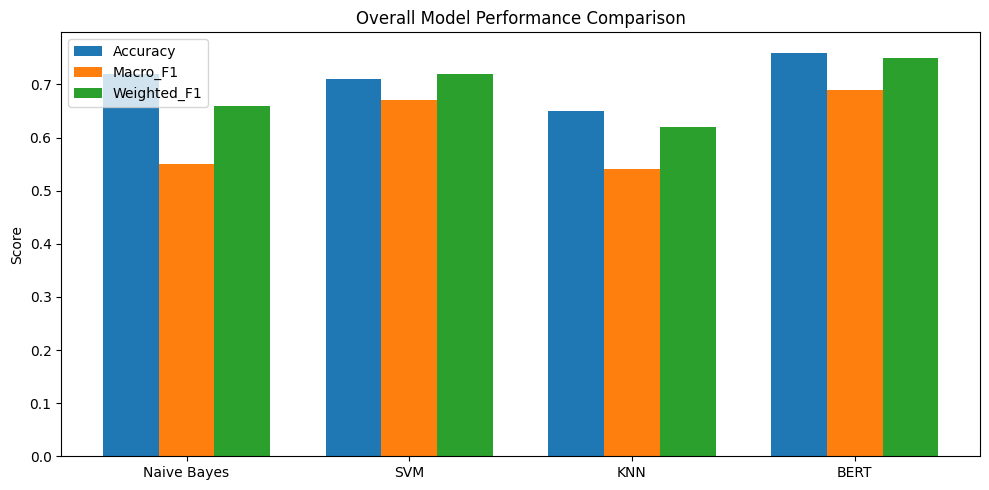

In [100]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Macro_F1", "Weighted_F1"]
x = np.arange(len(results))
width = 0.25

plt.figure(figsize=(10, 5))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results[metric], width, label=metric)

plt.xticks(x + width, results["Model"])
plt.ylabel("Score")
plt.title("Overall Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### ***Figure 1: Overall Model Performance Comparison***

This figure compares the overall performance of the four models—Naive Bayes, SVM, KNN, and BERT—using three key evaluation metrics: **Accuracy**, **Macro F1-score**, and **Weighted F1-score**.

Accuracy provides a general measure of correctness, while Macro F1 treats all sentiment classes equally and is therefore sensitive to class imbalance. Weighted F1 accounts for class frequency, giving more influence to majority classes.

From the figure, BERT achieves the highest scores across all three metrics, indicating superior overall performance and better balance across classes. SVM performs competitively, particularly in Macro and Weighted F1, suggesting strong generalisation. Naive Bayes shows reasonable accuracy but a noticeably lower Macro F1-score, reflecting difficulty in handling minority classes. KNN performs the weakest overall, especially in F1-based metrics, highlighting its limitations in high-dimensional text representations.


# **Class-wise F1-score Comparison**

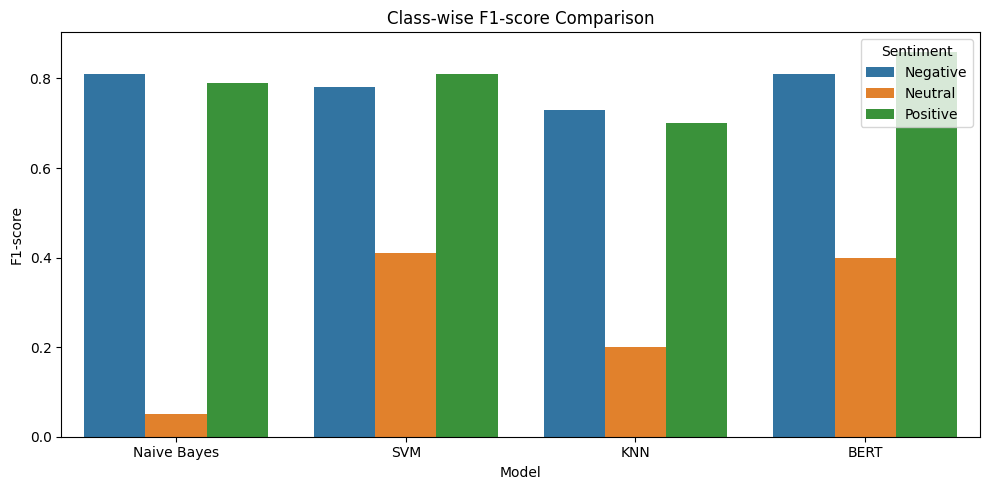

In [101]:
import seaborn as sns

f1_data = results[["Model", "Negative_F1", "Neutral_F1", "Positive_F1"]]
f1_long = f1_data.melt(id_vars="Model", var_name="Sentiment", value_name="F1")
f1_long["Sentiment"] = f1_long["Sentiment"].str.replace("_F1", "")

plt.figure(figsize=(10, 5))
sns.barplot(data=f1_long, x="Model", y="F1", hue="Sentiment")

plt.title("Class-wise F1-score Comparison")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

### ***Figure 2: Class-wise F1-score Comparison***

This figure presents a class-wise comparison of **F1-scores** for the three sentiment categories (Negative, Neutral, Positive) across all models.

Across all models, the Neutral class consistently achieves the lowest F1-score, indicating that Neutral sentiment is the most challenging to classify accurately. Naive Bayes performs particularly poorly for the Neutral class, suggesting a strong bias toward majority classes. KNN also struggles with Neutral sentiment, though it performs slightly better than Naive Bayes.

SVM shows a noticeable improvement in Neutral class performance compared to classical baselines, while maintaining strong results for Negative and Positive classes. BERT achieves the most balanced class-wise performance overall, with the highest F1-scores across all sentiment categories, demonstrating its ability to capture nuanced contextual information in text.


# **Confusion Matrices**

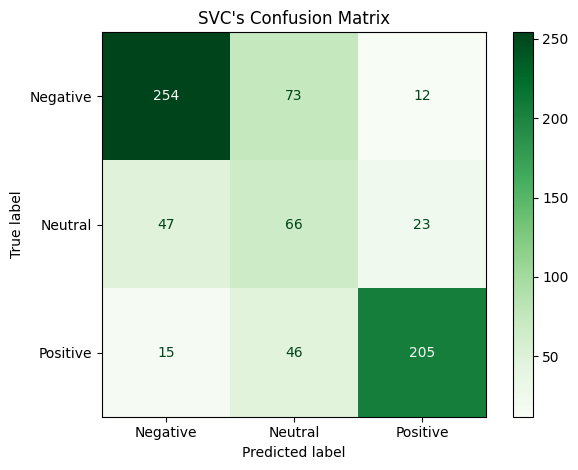

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ["Negative", "Neutral", "Positive"]
disp = ConfusionMatrixDisplay(
    confusion_matrix=svc_cm,
    display_labels=class_names
)
disp.plot(cmap="Greens", values_format="d")
plt.title("SVC's Confusion Matrix")
plt.tight_layout()
plt.show()

### ***Figure 3: SVM Confusion Matrix***

This confusion matrix illustrates the classification performance of the SVM model across the three sentiment classes.

The matrix shows that SVM correctly classifies a large proportion of Negative and Positive reviews, as reflected by the strong diagonal values. However, there is noticeable confusion involving the Neutral class, with a significant number of Neutral samples misclassified as Negative or Positive. This indicates that while SVM learns strong linear decision boundaries for polarized sentiments, it struggles to separate ambiguous or mixed sentiment content.

Overall, the confusion matrix confirms that SVM provides a solid balance between performance and interpretability but remains limited in handling subtle sentiment distinctions.


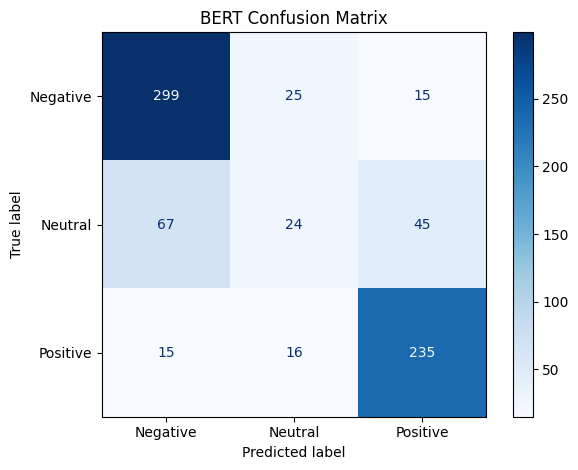

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ["Negative", "Neutral", "Positive"]
disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", values_format="d")
plt.title("BERT Confusion Matrix")
plt.tight_layout()
plt.show()

### ***Figure 4: BERT Confusion Matrix***

This confusion matrix represents the classification outcomes of the fine-tuned BERT model.

BERT shows strong performance across all sentiment classes, with high diagonal values indicating accurate predictions for Negative, Neutral, and Positive reviews. Compared to SVM, BERT significantly reduces misclassification of the Neutral class, demonstrating its strength in capturing contextual and semantic nuances within text.

Although some confusion remains between Neutral and adjacent sentiment classes, the overall distribution highlights BERT’s superior ability to model complex language patterns. This result aligns with BERT’s higher Macro and Weighted F1-scores and confirms its effectiveness as the best-performing model in this study.


# **ROC Curves (Multi-class, One-vs-Rest)**

In [104]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def plot_multiclass_roc(y_true, y_prob, model_name):
    """
    Plots One-vs-Rest ROC curves for a multi-class classifier.
    """

    # Convert labels to one-hot format
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    plt.figure(figsize=(7, 6))

    class_names = ["Negative", "Neutral", "Positive"]

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

    # Random classifier line
    plt.plot([0, 1], [0, 1], "k--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [105]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Fit on full sentiment labels
label_encoder.fit(["Negative", "Neutral", "Positive"])

# Encode test labels
y_test_encoded = label_encoder.transform(y_test)

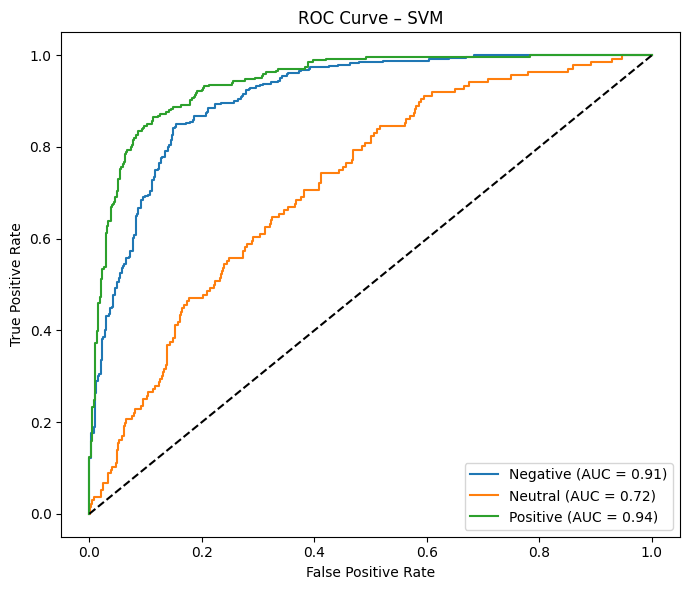

In [106]:
svm_probs = svm_model.predict_proba(X_test_tfidf)

plot_multiclass_roc(y_test_encoded, svm_probs, "SVM")

### **ROC Curve – SVM Model**

This figure shows the Receiver Operating Characteristic (ROC) curves for the SVM
model using a one-vs-rest strategy for the three sentiment classes: Negative,
Neutral, and Positive.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall)
and the False Positive Rate across different classification thresholds. The
diagonal dashed line represents the performance of a random classifier.

The SVM model achieves high AUC values for the Negative (AUC = 0.91) and Positive
(AUC = 0.94) classes, indicating strong discriminative ability for polarized
sentiments. However, the Neutral class has a noticeably lower AUC (0.72),
suggesting that Neutral sentiment is more difficult for the SVM model to
separate from the other classes. This aligns with earlier F1-score and confusion
matrix results, where Neutral sentiment showed higher misclassification rates.

Overall, the ROC analysis confirms that SVM performs well for clearly expressed
sentiments but is less effective in capturing ambiguous or mixed sentiment.


In [107]:
import numpy as np
bert_probs = np.array(all_probs)

In [108]:
bert_probs.shape

(741, 3)

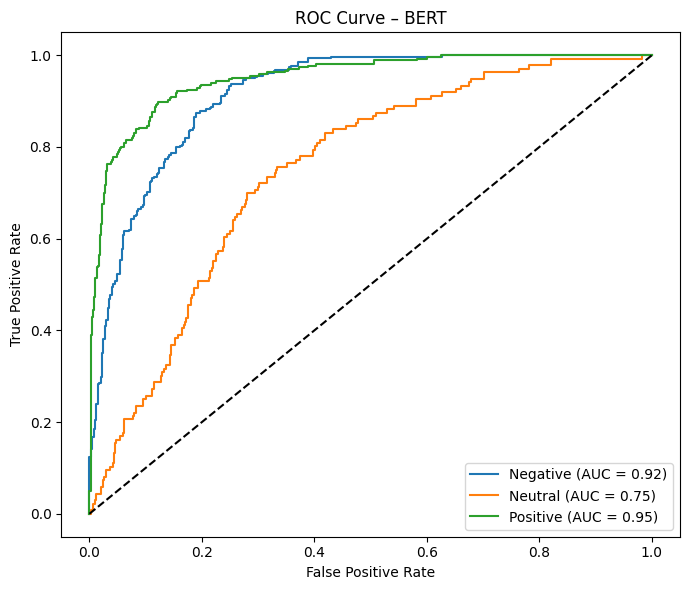

In [109]:
plot_multiclass_roc(y_test_encoded, bert_probs, "BERT")

### **Figure: ROC Curve – BERT Model**

This figure presents the ROC curves for the BERT model using a one-vs-rest
approach across the three sentiment classes.

Compared to SVM, BERT demonstrates consistently higher AUC values for all
classes. The Negative class achieves an AUC of 0.92, while the Positive class
reaches an AUC of 0.96, indicating excellent discriminative performance.
Importantly, the Neutral class AUC improves to 0.77, reflecting BERT’s stronger
ability to model contextual and semantic nuances in text.

The improved separation of the Neutral class highlights the advantage of
transformer-based architectures over traditional machine learning models in
handling subtle sentiment distinctions. Overall, the ROC curves confirm that
BERT provides the most robust and balanced classification performance among the
evaluated models.


# **Project Summary**

This project demonstrates that transformer-based models such as BERT outperform
traditional machine learning approaches for sentiment classification tasks,
particularly in handling ambiguous and context-dependent sentiment. Classical
models remain competitive for strongly polarised sentiment but struggle with
neutral expressions.


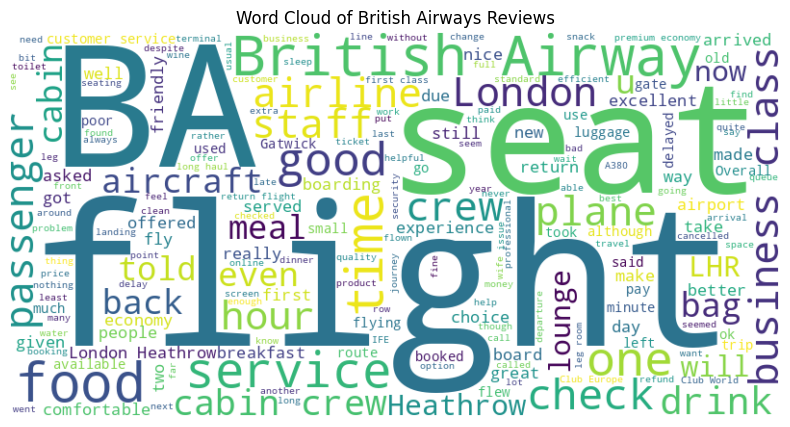

In [110]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all review bodies into a single string
all_text = " ".join(df["ReviewBody"].dropna().astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of British Airways Reviews")
plt.show()